Notebook Feature Engineering + modelo

In [4]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Importar datos student_model_processed
df = pd.read_csv('../DATA/PROCESSED/student_model_processed.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

In [6]:
# Feature Engineering
# Claude
df['avg_grade'] = (df['G1'] + df['G2']) / 2
df['parent_edu_avg'] = (df['Medu'] + df['Fedu']) / 2
df['alcohol_total'] = df['Dalc'] + df['Walc']
df['absence_rate'] = df['absences'] / df['absences'].max()

In [7]:
# Principales datos estadisticos del dataframe
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1044.0,16.726054,1.239975,15.0,16.0,17.000000,18.00,22.0
Medu,1044.0,2.603448,1.124907,0.0,2.0,3.000000,4.00,4.0
Fedu,1044.0,2.387931,1.099938,0.0,1.0,2.000000,3.00,4.0
traveltime,1044.0,1.522989,0.731727,1.0,1.0,1.000000,2.00,4.0
studytime,1044.0,1.970307,0.834353,1.0,1.0,2.000000,2.00,4.0
failures,1044.0,0.264368,0.656142,0.0,0.0,0.000000,0.00,3.0
famrel,1044.0,3.935824,0.933401,1.0,4.0,4.000000,5.00,5.0
freetime,1044.0,3.201149,1.031507,1.0,3.0,3.000000,4.00,5.0
goout,1044.0,3.156130,1.152575,1.0,2.0,3.000000,4.00,5.0
Dalc,1044.0,1.494253,0.911714,1.0,1.0,1.000000,2.00,5.0


In [8]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'subject', 'G3', 'risk_level',
       'avg_grade', 'parent_edu_avg', 'alcohol_total', 'absence_rate'],
      dtype='str')

In [9]:
# Eliminar risk_level porque el modelo es de regresión
df = df.drop('risk_level', axis=1)

<Axes: >

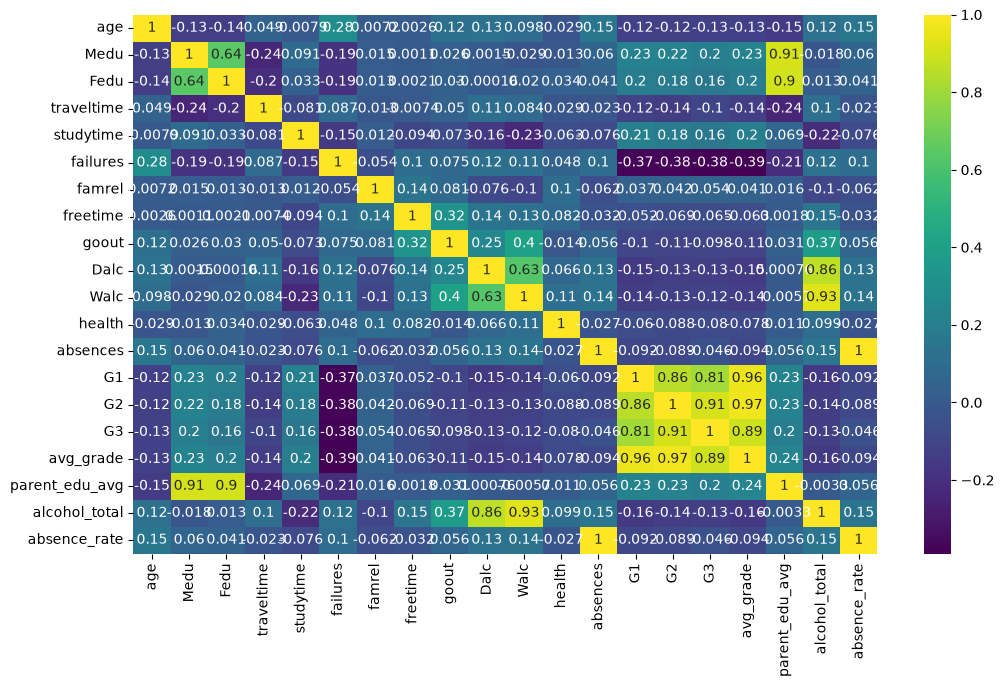

In [10]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only = True),annot=True,cmap='viridis')

In [11]:
# Mostrar categoricas para transformar
df.select_dtypes(include='object').columns

C:\Users\isaac\AppData\Local\Temp\ipykernel_21240\59492462.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'subject'],
      dtype='str')

In [12]:
# Variables para transformar
categoricas = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'subject']

dummies = pd.get_dummies(df[categoricas],drop_first=True)

df_post = pd.concat([df,dummies],axis=1)
df_post = df_post.drop(categoricas, axis=1)
df_post.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1044 non-null   int64  
 1   Medu                1044 non-null   int64  
 2   Fedu                1044 non-null   int64  
 3   traveltime          1044 non-null   int64  
 4   studytime           1044 non-null   int64  
 5   failures            1044 non-null   int64  
 6   famrel              1044 non-null   int64  
 7   freetime            1044 non-null   int64  
 8   goout               1044 non-null   int64  
 9   Dalc                1044 non-null   int64  
 10  Walc                1044 non-null   int64  
 11  health              1044 non-null   int64  
 12  absences            1044 non-null   int64  
 13  G1                  1044 non-null   int64  
 14  G2                  1044 non-null   int64  
 15  G3                  1044 non-null   int64  
 16  avg_grade        

In [13]:
# Muchos valores son booleanos entonces hay que convertir a INT para la regresion
# Código de Claude
bool_cols = df_post.select_dtypes(include='bool').columns
df_post[bool_cols] = df_post[bool_cols].astype(int)

# Verificamos
print(df_post.dtypes.value_counts())

int64      44
float64     3
Name: count, dtype: int64


X y Y Train test split data

In [14]:
X = df_post.drop(columns=['G3'])

In [15]:
y = df_post['G3']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [18]:
X_train.shape

(835, 46)

In [19]:
X_test.shape

(209, 46)

Escalado

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [21]:
X_train

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,subject_portuguese
399,16,3,3,1,2,0,4,3,2,1,...,0,0,1,0,0,1,1,0,0,1
8,15,3,2,1,2,0,4,2,2,1,...,0,0,1,1,0,1,1,1,0,0
400,16,4,3,1,2,0,5,4,2,1,...,0,0,1,0,1,1,1,1,0,1
631,16,2,3,1,2,0,2,3,1,1,...,0,1,0,0,0,1,1,1,0,1
367,17,1,1,3,1,1,5,2,1,1,...,0,0,1,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,16,2,2,1,2,0,4,3,5,2,...,0,0,0,0,0,1,0,1,0,1
973,17,3,3,2,2,1,4,5,4,2,...,0,0,1,0,0,1,1,1,0,1
75,15,4,3,1,2,0,4,3,3,2,...,0,0,1,1,1,1,1,1,0,0
599,16,2,3,1,2,0,4,3,3,1,...,0,0,0,0,0,1,1,1,0,1


In [22]:
X_train= scaler.fit_transform(X_train)

In [23]:
X_train

array([[0.14285714, 0.75      , 0.75      , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.75      , 0.5       , ..., 1.        , 0.        ,
        0.        ],
       [0.14285714, 1.        , 0.75      , ..., 1.        , 0.        ,
        1.        ],
       ...,
       [0.        , 1.        , 0.75      , ..., 1.        , 0.        ,
        0.        ],
       [0.14285714, 0.5       , 0.75      , ..., 1.        , 0.        ,
        1.        ],
       [0.        , 0.5       , 0.5       , ..., 0.        , 0.        ,
        1.        ]], shape=(835, 46))

In [24]:
X_test = scaler.transform(X_test)

In [25]:
X_train.shape

(835, 46)

In [26]:
X_test.shape

(209, 46)

Creacion del modelo

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

In [28]:
model = Sequential()

# Numero de neuronas
num_neuronas = X_train.shape[1]

model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(1)) # 1 sola neurona de salida G3

model.compile(optimizer='adam',loss='mse')


In [29]:
model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values), #si indicamos validation_data en cada epoch calcula sobre el conjunto de test el resultado de pérdidas
          batch_size=32,epochs=25) #batch_size es el tamaño de datos que toma en cada cálculo (indicar potencia de 2) / epochs es el número de iteraciones sobre la red neuronal para ajustar los pesos (w) y bias (b)

Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 92.7963 - val_loss: 17.4627
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.7498 - val_loss: 15.2072
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.9805 - val_loss: 13.5700
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.0212 - val_loss: 11.8559
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.9809 - val_loss: 10.4068
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.2387 - val_loss: 8.5830
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0503 - val_loss: 7.7275
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4253 - val_loss: 6.5310
Epoch 9/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8729 - val_loss: 5.8466
Epoch 10/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2868 - val_loss: 5.1901
Epoch 11/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8526 - val_loss: 4.9958
Epoch 12/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5022

In [30]:
losses = pd.DataFrame(model.history.history)# perdidas de muestro modelo(loss) y el de test(val_loss)

In [31]:
losses

,loss,val_loss
0,92.796333,17.462696
1,16.749819,15.207196
2,12.980474,13.569977
3,11.021173,11.855917
4,8.980885,10.406832
5,7.238677,8.582968
6,6.050349,7.727525
7,5.425321,6.530998
8,4.872909,5.846571
9,4.286800,5.190083


<Axes: >

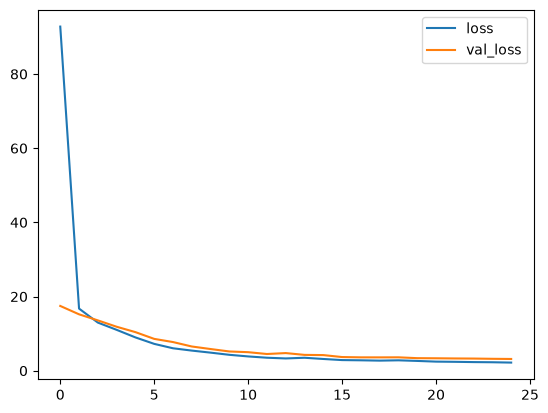

In [32]:
losses.plot()

Evaluación del modeloEvaluacion del modelo
https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics



In [33]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score

In [34]:
X_test

array([[0.14285714, 0.75      , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.28571429, 1.        , 0.75      , ..., 1.        , 1.        ,
        0.        ],
       [0.14285714, 0.5       , 0.25      , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [0.42857143, 1.        , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.42857143, 0.25      , 0.75      , ..., 1.        , 1.        ,
        0.        ],
       [0.28571429, 0.75      , 0.75      , ..., 1.        , 0.        ,
        1.        ]], shape=(209, 46))

In [35]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [36]:
# Metricas
mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))
r2 = r2_score(y_test,predictions)
evs = explained_variance_score(y_test,predictions)

print(evs)
print(mae)
print(rmse)
print(r2)

0.8073683977127075
1.1795867681503296
1.7796424170084764
0.8064002394676208


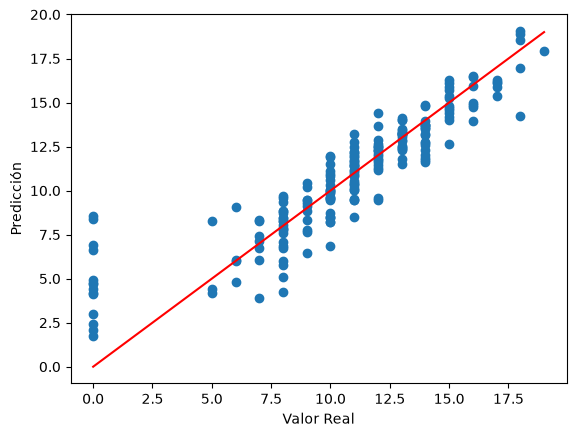

In [37]:
# Visualizar nuestra predicción
plt.scatter(y_test,predictions)
plt.xlabel("Valor Real")
plt.ylabel("Predicción")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.show()

In [38]:
errors = y_test.values.reshape(y_test.shape[0], 1) - predictions #rotar y_test para poder comparar con predictions

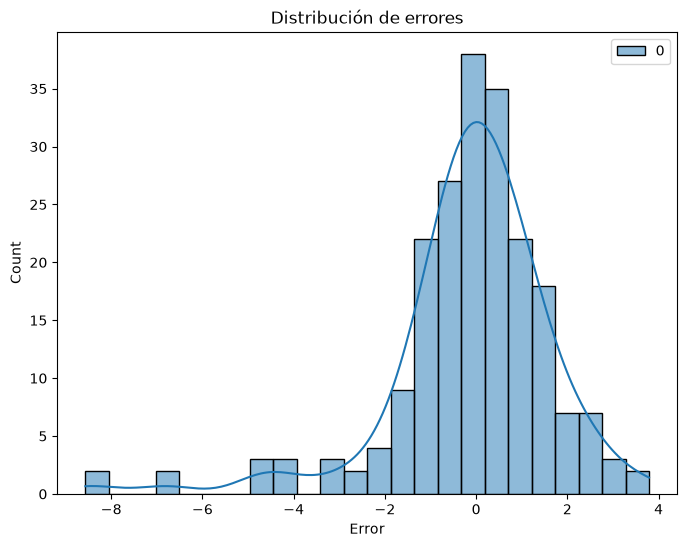

In [39]:
plt.figure(figsize=(8,6))

sns.histplot(errors, kde=True)

plt.xlabel("Error")
plt.title("Distribución de errores")

plt.show()

In [40]:
# Compara Real vs Prediccion
resultado = pd.DataFrame({
    'Real': y_test.values,
    'Prediccion': predictions.flatten()
})
resultado.head(20)

,Real,Prediccion
0,11,10.052723
1,13,14.028777
2,16,14.950455
3,11,11.095058
4,10,11.922566
5,8,8.273738
6,15,14.432198
7,8,6.856668
8,5,8.255719
9,9,9.273998


In [41]:
# Variables para la API
print(X.shape)
print(X.columns.tolist())

(1044, 46)
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'avg_grade', 'parent_edu_avg', 'alcohol_total', 'absence_rate', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'subject_portuguese']


In [42]:
model.save(r'C:\Users\fabia\Documents\GitHub\Prediccion-rendimiento-academico\MODELS\model1_featureengineering.h5')

PermissionError: [WinError 5] Acceso denegado: 'C:\\Users\\fabia'